## Loan Default Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)
import scorecardpy as sc

## 1. DATA UNDERSTANDING

In [2]:
df = pd.read_csv("C:\\Users\\HP\\Downloads\\archive (16)\\Loan_Default.csv")
print(df.shape)                 # (148670, 34)
print(list(df.columns))
print(df.isnull().sum())
print(df['Status'].value_counts())

(148670, 34)
['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']
ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         366

In [3]:
num_cols = df.select_dtypes(include=['number']).columns
print((df[num_cols] == 0).sum().sort_values(ascending=False))
print(df[num_cols].describe().T[['min', 'max']])

Status                  112031
Upfront_charges          20770
income                    1260
Interest_rate_spread         9
rate_of_interest             1
year                         0
loan_amount                  0
ID                           0
term                         0
property_value               0
Credit_Score                 0
LTV                          0
dtir1                        0
dtype: int64
                               min           max
ID                    24890.000000  1.735590e+05
year                   2019.000000  2.019000e+03
loan_amount           16500.000000  3.576500e+06
rate_of_interest          0.000000  8.000000e+00
Interest_rate_spread     -3.638000  3.357000e+00
Upfront_charges           0.000000  6.000000e+04
term                     96.000000  3.600000e+02
property_value         8000.000000  1.650800e+07
income                    0.000000  5.785800e+05
Credit_Score            500.000000  9.000000e+02
LTV                       0.967478  7.831250e

In [4]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


loan_limit
loan_limit
cf     135348
ncf      9978
NaN      3344
Name: count, dtype: int64

Gender
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

approv_in_adv
approv_in_adv
nopre    124621
pre       23141
NaN         908
Name: count, dtype: int64

loan_type
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

loan_purpose
loan_purpose
p3     55934
p4     54799
p1     34529
p2      3274
NaN      134
Name: count, dtype: int64

Credit_Worthiness
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64

open_credit
open_credit
nopc    148114
opc        556
Name: count, dtype: int64

business_or_commercial
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64

Neg_ammortization
Neg_ammortization
not_neg    133420
neg_amm     15129
NaN           121
Name: count, dtype: int64

interest_only
interest_only
not_int     141560
int_

## 1.1 DATA PRE-PROCESSING / CLEANING

In [5]:
df = df.drop(columns=['ID', 'loan_limit', 'approv_in_adv'])

In [6]:
# --- loan_purpose: mode imputation ---
df['loan_purpose'] = df['loan_purpose'].fillna(df['loan_purpose'].mode()[0])

In [7]:
# --- income: bucketed (by loan_amount decile) median imputation ---
df['income'] = df['income'].replace(0, np.nan)
income_non_null = df[df['income'].notna()].copy()
income_null = df[df['income'].isna()].copy()

In [8]:
income_non_null['loan_bucket'] = pd.qcut(
    income_non_null['loan_amount'], q=10, labels=False, duplicates='drop'
)
bucket_median = income_non_null.groupby('loan_bucket')['income'].median()
loan_bins = pd.qcut(income_non_null['loan_amount'], q=10, retbins=True, duplicates='drop')[1]
income_null['loan_bucket'] = pd.cut(
    income_null['loan_amount'], bins=loan_bins, labels=False, include_lowest=True
)
income_null['income'] = income_null['loan_bucket'].map(bucket_median)

In [9]:
income_non_null.drop(columns='loan_bucket', inplace=True)
income_null.drop(columns='loan_bucket', inplace=True)
df = pd.concat([income_non_null, income_null]).sort_index()
df['income'] = df['income'].fillna(df['income'].median())
print(df['income'].isnull().sum())  # 0

0


In [10]:
# --- rate_of_interest: bucketed (loan_amount x income) median imputation ---
df['rate_of_interest'] = df['rate_of_interest'].replace(0, np.nan)
roi_non_null = df[df['rate_of_interest'].notna()].copy()
roi_null = df[df['rate_of_interest'].isna()].copy()

In [11]:
roi_non_null['loan_bucket'] = pd.qcut(roi_non_null['loan_amount'], q=5, labels=False, duplicates='drop')
roi_non_null['income_bucket'] = pd.qcut(roi_non_null['income'], q=5, labels=False, duplicates='drop')
bucket_median = roi_non_null.groupby(['loan_bucket', 'income_bucket'])['rate_of_interest'].median()

In [12]:
loan_bins = pd.qcut(roi_non_null['loan_amount'], q=5, retbins=True, duplicates='drop')[1]
income_bins = pd.qcut(roi_non_null['income'], q=5, retbins=True, duplicates='drop')[1]

In [13]:
roi_null['loan_bucket'] = pd.cut(roi_null['loan_amount'], bins=loan_bins, labels=False, include_lowest=True)
roi_null['income_bucket'] = pd.cut(roi_null['income'], bins=income_bins, labels=False, include_lowest=True)
roi_null['rate_of_interest'] = roi_null.apply(
    lambda x: bucket_median.get((x['loan_bucket'], x['income_bucket']), np.nan), axis=1
)

In [14]:
roi_non_null.drop(columns=['loan_bucket', 'income_bucket'], inplace=True)
roi_null.drop(columns=['loan_bucket', 'income_bucket'], inplace=True)
df = pd.concat([roi_non_null, roi_null]).sort_index()
df['rate_of_interest'] = df['rate_of_interest'].fillna(df['rate_of_interest'].median())
print(df['rate_of_interest'].isnull().sum())  # 0

0


In [15]:
# --- property_value: bucketed (by loan_amount decile) median imputation ---
pv_non_null = df[df['property_value'].notna()].copy()
pv_null = df[df['property_value'].isna()].copy()

In [16]:
pv_non_null['loan_bucket'] = pd.qcut(pv_non_null['loan_amount'], q=10, labels=False, duplicates='drop')
bucket_median = pv_non_null.groupby('loan_bucket')['property_value'].median()
loan_bins = pd.qcut(pv_non_null['loan_amount'], q=10, retbins=True, duplicates='drop')[1]
pv_null['loan_bucket'] = pd.cut(pv_null['loan_amount'], bins=loan_bins, labels=False, include_lowest=True)
pv_null['property_value'] = pv_null['loan_bucket'].map(bucket_median)

In [17]:
pv_non_null.drop(columns='loan_bucket', inplace=True)
pv_null.drop(columns='loan_bucket', inplace=True)
df = pd.concat([pv_non_null, pv_null]).sort_index()
df['property_value'] = df['property_value'].fillna(df['property_value'].median())
print(df['property_value'].isnull().sum())  # 0

0


In [18]:
# --- Upfront_charges: bucketed (loan_amount x property_value) median imputation ---
uc_non_null = df[df['Upfront_charges'].notna()].copy()
uc_null = df[df['Upfront_charges'].isna()].copy()

In [19]:
uc_non_null['loan_bucket'] = pd.qcut(uc_non_null['loan_amount'], q=5, labels=False, duplicates='drop')
uc_non_null['property_bucket'] = pd.qcut(uc_non_null['property_value'], q=5, labels=False, duplicates='drop')
bucket_median = uc_non_null.groupby(['loan_bucket', 'property_bucket'])['Upfront_charges'].median()

In [20]:
loan_bins = pd.qcut(uc_non_null['loan_amount'], q=5, retbins=True, duplicates='drop')[1]
property_bins = pd.qcut(uc_non_null['property_value'], q=5, retbins=True, duplicates='drop')[1]

In [21]:
uc_null['loan_bucket'] = pd.cut(uc_null['loan_amount'], bins=loan_bins, labels=False, include_lowest=True)
uc_null['property_bucket'] = pd.cut(uc_null['property_value'], bins=property_bins, labels=False, include_lowest=True)
uc_null['Upfront_charges'] = uc_null.apply(
    lambda x: bucket_median.get((x['loan_bucket'], x['property_bucket']), np.nan), axis=1
)

In [22]:
uc_non_null.drop(columns=['loan_bucket', 'property_bucket'], inplace=True)
uc_null.drop(columns=['loan_bucket', 'property_bucket'], inplace=True)
df = pd.concat([uc_non_null, uc_null]).sort_index()
df['Upfront_charges'] = df['Upfront_charges'].fillna(df['Upfront_charges'].median())
print(df['Upfront_charges'].isnull().sum())  # 0

0


In [23]:
# --- Interest_rate_spread: bucketed (by rate_of_interest decile) median imputation ---
irs_non_null = df[df['Interest_rate_spread'].notna()].copy()
irs_null = df[df['Interest_rate_spread'].isna()].copy()

In [24]:
irs_non_null['roi_bucket'] = pd.qcut(irs_non_null['rate_of_interest'], q=10, labels=False, duplicates='drop')
bucket_median = irs_non_null.groupby('roi_bucket')['Interest_rate_spread'].median()
roi_bins = pd.qcut(irs_non_null['rate_of_interest'], q=10, retbins=True, duplicates='drop')[1]
irs_null['roi_bucket'] = pd.cut(irs_null['rate_of_interest'], bins=roi_bins, labels=False, include_lowest=True)
irs_null['Interest_rate_spread'] = irs_null['roi_bucket'].map(bucket_median)

In [25]:
irs_non_null.drop(columns='roi_bucket', inplace=True)
irs_null.drop(columns='roi_bucket', inplace=True)
df = pd.concat([irs_non_null, irs_null]).sort_index()
df['Interest_rate_spread'] = df['Interest_rate_spread'].fillna(df['Interest_rate_spread'].median())
print(df['Interest_rate_spread'].isnull().sum())  # 0

0


In [26]:
print(df[['rate_of_interest', 'Interest_rate_spread']].corr())
print(df.isnull().sum())

                      rate_of_interest  Interest_rate_spread
rate_of_interest              1.000000              0.612541
Interest_rate_spread          0.612541              1.000000
year                             0
Gender                           0
loan_type                        0
loan_purpose                     0
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest                 0
Interest_rate_spread             0
Upfront_charges                  0
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value                   0
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                           0
credit_type                      0
Credit_Score                     0
co-applicant

In [27]:
# --- drop low-value / near-constant field ---
df = df.drop(columns=['submission_of_application'])

In [28]:
# --- term: median imputation ---
df['term'] = df['term'].fillna(df['term'].median())
print(df['term'].isnull().sum())  # 0

0


In [29]:
# --- Neg_ammortization: mode imputation ---
df['Neg_ammortization'] = df['Neg_ammortization'].fillna(df['Neg_ammortization'].mode()[0])
print(df['Neg_ammortization'].isnull().sum())  # 0

0


In [30]:
# --- dtir1: bucketed (loan_amount x income) median imputation ---
dti_non_null = df[df['dtir1'].notna()].copy()
dti_null = df[df['dtir1'].isna()].copy()

In [31]:
dti_non_null['loan_bucket'] = pd.qcut(dti_non_null['loan_amount'], q=5, labels=False, duplicates='drop')
dti_non_null['income_bucket'] = pd.qcut(dti_non_null['income'], q=5, labels=False, duplicates='drop')
bucket_median = dti_non_null.groupby(['loan_bucket', 'income_bucket'])['dtir1'].median()

In [32]:
loan_bins = pd.qcut(dti_non_null['loan_amount'], q=5, retbins=True, duplicates='drop')[1]
income_bins = pd.qcut(dti_non_null['income'], q=5, retbins=True, duplicates='drop')[1]

In [33]:
dti_null['loan_bucket'] = pd.cut(dti_null['loan_amount'], bins=loan_bins, labels=False, include_lowest=True)
dti_null['income_bucket'] = pd.cut(dti_null['income'], bins=income_bins, labels=False, include_lowest=True)
dti_null['dtir1'] = dti_null.apply(
    lambda x: bucket_median.get((x['loan_bucket'], x['income_bucket']), np.nan), axis=1
)

In [34]:
dti_non_null.drop(columns=['loan_bucket', 'income_bucket'], inplace=True)
dti_null.drop(columns=['loan_bucket', 'income_bucket'], inplace=True)
df = pd.concat([dti_non_null, dti_null]).sort_index()
df['dtir1'] = df['dtir1'].fillna(df['dtir1'].median())
print(df['dtir1'].isnull().sum())  # 0

0


In [35]:
# --- LTV: recompute from loan_amount / property_value wherever missing ---
df.loc[df['LTV'].isna(), 'LTV'] = (
    df.loc[df['LTV'].isna(), 'loan_amount'] /
    df.loc[df['LTV'].isna(), 'property_value']
) * 100
print(df.isnull().sum())

year                          0
Gender                        0
loan_type                     0
loan_purpose                  0
Credit_Worthiness             0
open_credit                   0
business_or_commercial        0
loan_amount                   0
rate_of_interest              0
Interest_rate_spread          0
Upfront_charges               0
term                          0
Neg_ammortization             0
interest_only                 0
lump_sum_payment              0
property_value                0
construction_type             0
occupancy_type                0
Secured_by                    0
total_units                   0
income                        0
credit_type                   0
Credit_Score                  0
co-applicant_credit_type      0
age                         200
LTV                           0
Region                        0
Security_Type                 0
Status                        0
dtir1                         0
dtype: int64


## 1.1 EXPLORATORY DATA ANALYSIS

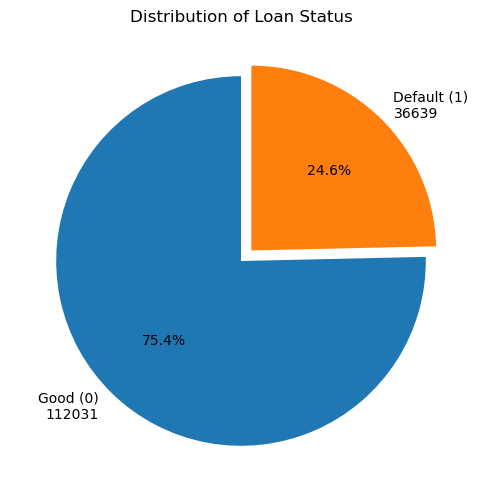

In [36]:
target_counts = df['Status'].value_counts().sort_index()
labels = [f"Good (0)\n{target_counts[0]}", f"Default (1)\n{target_counts[1]}"]
plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=labels, autopct='%1.1f%%', startangle=90, explode=(0, 0.08))
plt.title("Distribution of Loan Status")
plt.show()

       Region  Default Rate (%)
0  North-East         30.445344
1     central         27.538232
2       south         26.629280
3       North         22.511442


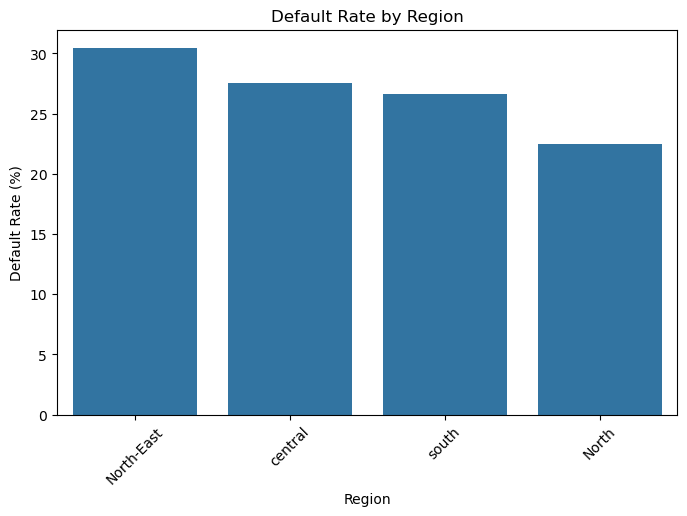

In [37]:
# 1. Default rate by Region
region_default = (
    df.groupby('Region')['Status'].mean().mul(100)
      .sort_values(ascending=False).reset_index(name='Default Rate (%)')
)
print(region_default)
plt.figure(figsize=(8, 5))
sns.barplot(data=region_default, x='Region', y='Default Rate (%)')
plt.xticks(rotation=45)
plt.title("Default Rate by Region")
plt.show()

  loan_purpose  Default Rate (%)
0           p2         33.078803
1           p1         25.876799
2           p3         25.024970
3           p4         22.974872


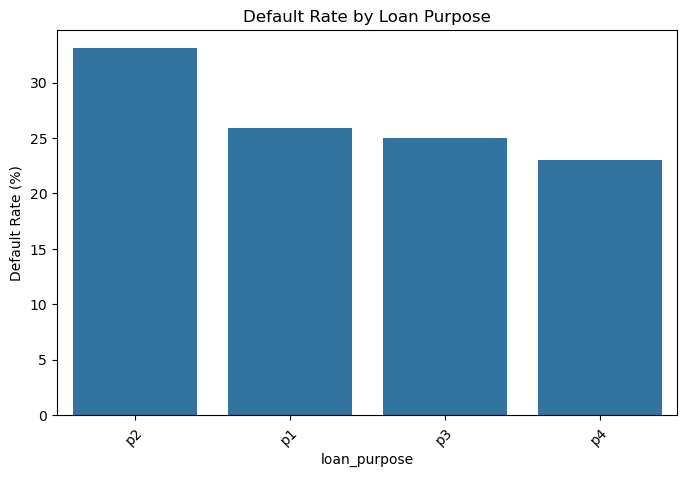

In [38]:
# 2. Default rate by Loan Purpose
purpose_default = (
    df.groupby('loan_purpose')['Status'].mean().mul(100)
      .sort_values(ascending=False).reset_index(name='Default Rate (%)')
)
print(purpose_default)
plt.figure(figsize=(8, 5))
sns.barplot(data=purpose_default, x='loan_purpose', y='Default Rate (%)')
plt.xticks(rotation=45)
plt.title("Default Rate by Loan Purpose")
plt.show()

  credit_type  Default Rate (%)
0        EQUI         99.993463
1        CRIF         16.234254
2         EXP         15.985382
3         CIB         15.804120


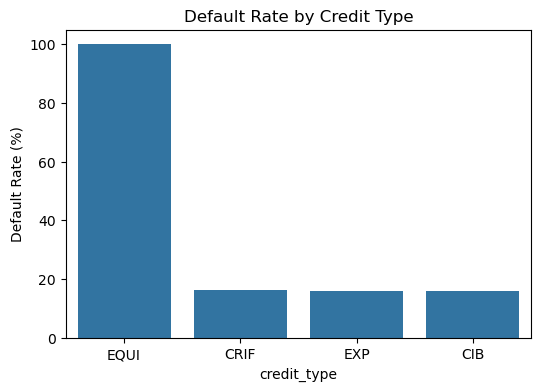

In [39]:
# 3. Default rate by Credit Type
credit_default = (
    df.groupby('credit_type')['Status'].mean().mul(100)
      .sort_values(ascending=False).reset_index(name='Default Rate (%)')
)
print(credit_default)
plt.figure(figsize=(6, 4))
sns.barplot(data=credit_default, x='credit_type', y='Default Rate (%)')
plt.title("Default Rate by Credit Type")
plt.show()

      Income Quartile  Default Rate (%)
0    (59.999, 3840.0]         33.028088
1    (3840.0, 5820.0]         24.362803
2    (5820.0, 8460.0]         20.943638
3  (8460.0, 578580.0]         20.135927


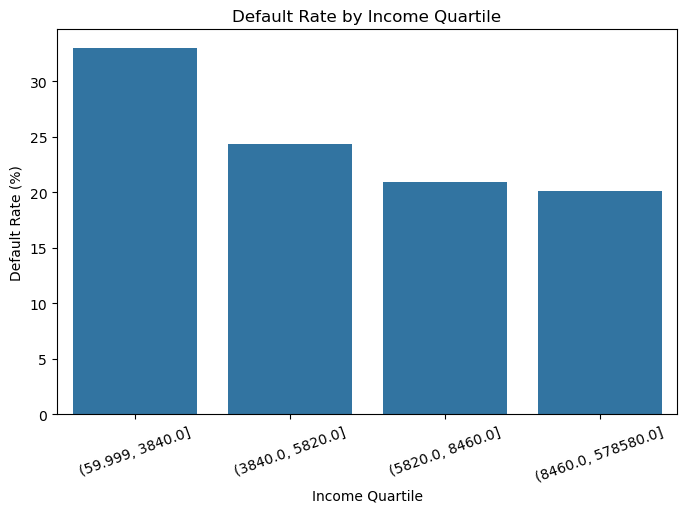

In [40]:
# 4. Default rate by Income Quartile
df['Income Quartile'] = pd.qcut(df['income'], 4)
income_default = (
    df.groupby('Income Quartile', observed=False)['Status'].mean().mul(100)
      .reset_index(name='Default Rate (%)')
)
print(income_default)
plt.figure(figsize=(8, 5))
sns.barplot(data=income_default, x='Income Quartile', y='Default Rate (%)')
plt.xticks(rotation=20)
plt.title("Default Rate by Income Quartile")
plt.show()

       LTV Bucket  Default Rate (%)
0  (-0.001, 60.0]         15.579448
1    (60.0, 70.0]         20.295711
2    (70.0, 80.0]         33.403125
3    (80.0, 90.0]         27.090027
4   (90.0, 100.0]         20.003441


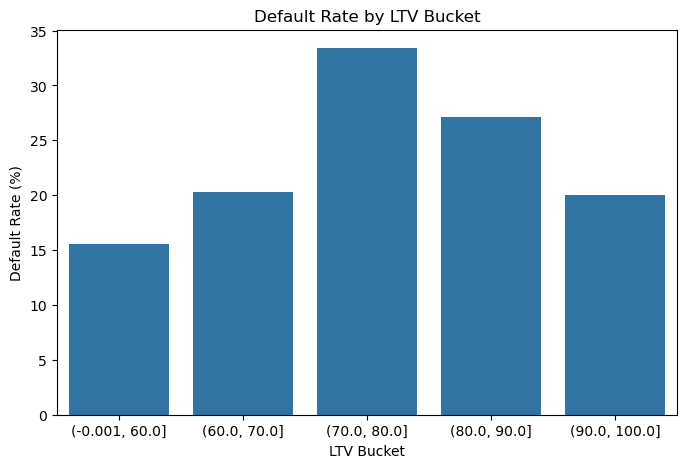

In [41]:
# 5. Default rate by LTV Bucket
df['LTV Bucket'] = pd.cut(df['LTV'], bins=[0, 60, 70, 80, 90, 100], include_lowest=True)
ltv_default = (
    df.groupby('LTV Bucket', observed=False)['Status'].mean().mul(100)
      .reset_index(name='Default Rate (%)')
)
print(ltv_default)
plt.figure(figsize=(8, 5))
sns.barplot(data=ltv_default, x='LTV Bucket', y='Default Rate (%)')
plt.title("Default Rate by LTV Bucket")
plt.show()

  Credit Score Bucket  Default Rate (%)
0    (299.999, 600.0]         24.617802
1      (600.0, 700.0]         24.501302
2      (700.0, 750.0]         24.148335
3      (750.0, 800.0]         24.368387
4      (800.0, 900.0]         25.196638


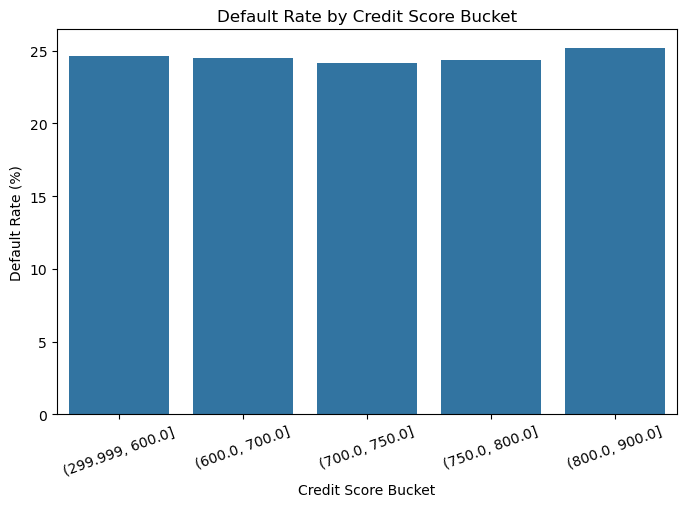

In [42]:
# 6. Default rate by Credit Score Bucket
df['Credit Score Bucket'] = pd.cut(
    df['Credit_Score'], bins=[300, 600, 700, 750, 800, 900], include_lowest=True
)
score_default = (
    df.groupby('Credit Score Bucket', observed=False)['Status'].mean().mul(100)
      .reset_index(name='Default Rate (%)')
)
print(score_default)
plt.figure(figsize=(8, 5))
sns.barplot(data=score_default, x='Credit Score Bucket', y='Default Rate (%)')
plt.xticks(rotation=20)
plt.title("Default Rate by Credit Score Bucket")
plt.show()

## 1.1.3 FEATURE ENGINEERING

In [43]:
df['loan_income_ratio'] = df['loan_amount'] / df['income']

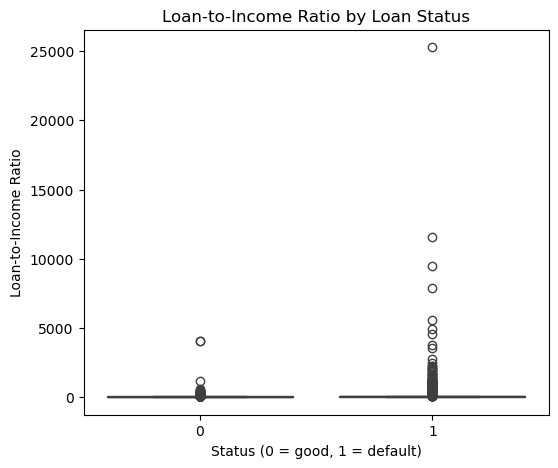

In [44]:
# Loan-to-income ratio vs. Status
plt.figure(figsize=(6, 5))
sns.boxplot(x='Status', y='loan_income_ratio', data=df)
plt.title("Loan-to-Income Ratio by Loan Status")
plt.xlabel("Status (0 = good, 1 = default)")
plt.ylabel("Loan-to-Income Ratio")
plt.show()

## 1.1.4 CANDIDATE ENGINEERED VARIABLES (to be tested, not assumed useful)

    payment_ratio          loan_amount / term
                            proxy for payment burden — loan_amount and
                            term individually have weak IV (0.07, 0.05),
                            but the two combined may say more about
                            affordability than either alone.

    leverage_score          dtir1 * loan_income_ratio
                            compounds two already-legitimate leverage
                            measures (existing debt burden and loan
                            size relative to income) into one score.

    credit_type_mismatch    credit_type != co-applicant_credit_type
                            flags whether the applicant and co-applicant
                            used different credit-reporting agencies —
                            a relationship between two categoricals that
                            doesn't exist as information in either column
                            alone.

In [45]:
df['payment_ratio'] = df['loan_amount'] / df['term']
df['leverage_score'] = df['dtir1'] * df['loan_income_ratio']
df['credit_type_mismatch'] = (
    df['credit_type'] != df['co-applicant_credit_type']
).astype(int)

## TRAIN / TEST SPLIT

In [46]:
train_df, test_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['Status']
)

## STATISTICAL SIGNIFICANCE TESTING

In [47]:
# Chi-square test (categorical variables) — engineered flags removed from list
cat_cols = [
    'Gender',
    'loan_type',
    'loan_purpose',
    'Region',
    'occupancy_type',
    'business_or_commercial',
    'Neg_ammortization',
    # Candidate engineered categorical variable (tested below via IV/VIF)
    'credit_type_mismatch',
]

In [48]:
results = []
for col in cat_cols:
    table = pd.crosstab(train_df[col], train_df['Status'])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append({
        'Variable': col, 'Chi2 Statistic': chi2, 'p_value': p,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

In [49]:
chi_results = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
print(chi_results)

                 Variable  Chi2 Statistic        p_value Significant
0       Neg_ammortization     2511.385872   0.000000e+00         Yes
1    credit_type_mismatch     1874.831556   0.000000e+00         Yes
2               loan_type      908.765686  4.613586e-198         Yes
3  business_or_commercial      886.756151  7.428447e-195         Yes
4                  Gender      749.401006  4.069253e-162         Yes
5                  Region      273.811059   4.623034e-59         Yes
6            loan_purpose      170.622935   9.336466e-37         Yes
7          occupancy_type      106.810363   6.403602e-24         Yes


In [50]:
# Mann-Whitney U test (continuous variables)
num_cols = [
    'loan_amount', 'income', 'Credit_Score', 'property_value', 'LTV',
    'dtir1', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges',
    # Engineered continuous variable (kept — real, non-redundant signal)
    'loan_income_ratio',
    # Candidate engineered continuous variables (tested below via IV/VIF)
    'payment_ratio', 'leverage_score',
]

In [51]:
results = []
for col in num_cols:
    good = train_df.loc[train_df['Status'] == 0, col].dropna()
    bad = train_df.loc[train_df['Status'] == 1, col].dropna()
    stat, p = mannwhitneyu(good, bad, alternative='two-sided')
    results.append({
        'Variable': col, 'U Statistic': stat, 'p_value': p,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

In [52]:
mw_results = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
print(mw_results)

                Variable   U Statistic        p_value Significant
0                 income  1.165497e+09   0.000000e+00         Yes
1         property_value  1.153628e+09  4.636638e-275         Yes
2         leverage_score  9.077773e+08  1.970598e-121         Yes
3          payment_ratio  1.100841e+09  5.055942e-115         Yes
4            loan_amount  1.099760e+09  1.717747e-112         Yes
5                  dtir1  9.121184e+08  2.957786e-111         Yes
6                    LTV  9.174165e+08   4.682632e-99         Yes
7      loan_income_ratio  9.236482e+08   8.091499e-86         Yes
8   Interest_rate_spread  9.364430e+08   8.596223e-62         Yes
9       rate_of_interest  9.532271e+08   1.310458e-36         Yes
10       Upfront_charges  1.033321e+09   3.199550e-11         Yes
11          Credit_Score  1.001522e+09   3.236348e-01          No


In [53]:
# Drop the EDA-only bucket columns before WOE binning
eda_cols = ['Income Quartile', 'LTV Bucket', 'Credit Score Bucket']
train_df = train_df.drop(columns=eda_cols, errors='ignore')
test_df = test_df.drop(columns=eda_cols, errors='ignore')

## 1.1.5  WOE BINNING

In [54]:
bins = sc.woebin(train_df, y='Status', positive='1')

[INFO] creating woe binning ...


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\scorecardpy\condition_fun.py:34: UserWarning: There are 1 columns have only one unique values, which are removed from input dataset. 
 (ColumnNames: year)
  warnings.warn("There are {} columns have only one unique values, which are removed from input dataset. \n (ColumnNames: {})".format(len(unique1_cols), ', '.join(unique1_cols)))
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime w

Binning on 104069 rows and 33 columns in 00:00:51


In [55]:
train_woe = sc.woebin_ply(train_df, bins)
test_woe = sc.woebin_ply(test_df, bins)

[INFO] converting into woe values ...
Woe transformating on 104069 rows and 32 columns in 00:00:17
[INFO] converting into woe values ...


## 1.1.6  INFORMATION VALUE

In [56]:
iv = sc.iv(train_df, y='Status', positive='1')
print(iv)

                    variable  info_value
0       Interest_rate_spread    5.363679
4                credit_type    4.551156
23          rate_of_interest    4.190477
22                       LTV    2.854636
26           Upfront_charges    2.721105
17            property_value    0.826325
24         loan_income_ratio    0.470574
9             leverage_score    0.303579
5                      dtir1    0.297302
25             payment_ratio    0.148172
11          lump_sum_payment    0.147085
20                    income    0.142563
21  co-applicant_credit_type    0.115064
1          Neg_ammortization    0.111636
19      credit_type_mismatch    0.106736
31               loan_amount    0.071332
27                      term    0.050079
15                       age    0.046501
2                  loan_type    0.043188
12    business_or_commercial    0.042029
6                     Gender    0.040400
14              Credit_Score    0.020327
10                    Region    0.014133
29              

In [57]:
CANDIDATE_VARS = ['payment_ratio', 'leverage_score', 'credit_type_mismatch']
IV_THRESHOLD = 0.02

In [58]:
candidate_iv = iv[iv['variable'].isin(CANDIDATE_VARS)]
print("\nIV for candidate engineered variables:")
print(candidate_iv)


IV for candidate engineered variables:
                variable  info_value
9         leverage_score    0.303579
25         payment_ratio    0.148172
19  credit_type_mismatch    0.106736


In [59]:
keep_candidates = candidate_iv.loc[
    candidate_iv['info_value'] > IV_THRESHOLD, 'variable'
].tolist()
drop_candidates_woe = [
    f"{c}_woe" for c in CANDIDATE_VARS if c not in keep_candidates
]

In [60]:
print(f"\nCandidates kept after IV screen (IV > {IV_THRESHOLD}): {keep_candidates}")
print(f"Candidates dropped (weak/redundant, same as the removed risk flags): "
      f"{[c for c in CANDIDATE_VARS if c not in keep_candidates]}")


Candidates kept after IV screen (IV > 0.02): ['leverage_score', 'payment_ratio', 'credit_type_mismatch']
Candidates dropped (weak/redundant, same as the removed risk flags): []


In [61]:
low_iv_drop = [
    'year',
    'open_credit_woe',
    'interest_only_woe',
    'construction_type_woe',
    'Secured_by_woe',
    'Security_Type_woe',
    'total_units_woe',
    'Credit_Worthiness_woe',
] + drop_candidates_woe

In [62]:
train_modelA = train_woe.drop(columns=low_iv_drop, errors='ignore').copy()
test_modelA = test_woe.drop(columns=low_iv_drop, errors='ignore').copy()

In [63]:
print(train_modelA.columns.tolist())

['Status', 'Interest_rate_spread_woe', 'Neg_ammortization_woe', 'loan_type_woe', 'occupancy_type_woe', 'credit_type_woe', 'dtir1_woe', 'Gender_woe', 'leverage_score_woe', 'Region_woe', 'lump_sum_payment_woe', 'business_or_commercial_woe', 'Credit_Score_woe', 'age_woe', 'property_value_woe', 'credit_type_mismatch_woe', 'income_woe', 'co-applicant_credit_type_woe', 'LTV_woe', 'rate_of_interest_woe', 'loan_income_ratio_woe', 'payment_ratio_woe', 'Upfront_charges_woe', 'term_woe', 'loan_purpose_woe', 'loan_amount_woe']


## 1.2  VIF (multicollinearity check) — Model A feature set

In [64]:
X_vif = train_modelA.drop(columns=['Status'])
vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif = vif.sort_values("VIF", ascending=False)
print(vif)

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


                        Variable        VIF
2                  loan_type_woe  37.873824
10    business_or_commercial_woe  37.122843
24               loan_amount_woe   3.584500
20             payment_ratio_woe   3.566765
7             leverage_score_woe   3.168317
19         loan_income_ratio_woe   2.808037
15                    income_woe   2.326576
0       Interest_rate_spread_woe   2.230726
18          rate_of_interest_woe   1.939980
16  co-applicant_credit_type_woe   1.781850
6                     Gender_woe   1.758535
21           Upfront_charges_woe   1.558512
13            property_value_woe   1.439449
4                credit_type_woe   1.324192
5                      dtir1_woe   1.201655
8                     Region_woe   1.182001
17                       LTV_woe   1.166506
23              loan_purpose_woe   1.080992
3             occupancy_type_woe   1.075210
14      credit_type_mismatch_woe   1.058880
12                       age_woe   1.053749
22                      term_woe

In [65]:
drop_vif = [
    'business_or_commercial_woe',
    'lump_sum_payment_woe',
]
train_modelA = train_modelA.drop(columns=drop_vif)
test_modelA = test_modelA.drop(columns=drop_vif)

In [66]:
X_vif = train_modelA.drop(columns=['Status'])
vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif = vif.sort_values("VIF", ascending=False)
print(vif)

                        Variable       VIF
22               loan_amount_woe  3.582920
18             payment_ratio_woe  3.564790
7             leverage_score_woe  3.167273
17         loan_income_ratio_woe  2.807954
13                    income_woe  2.326219
0       Interest_rate_spread_woe  2.210227
16          rate_of_interest_woe  1.923995
14  co-applicant_credit_type_woe  1.775774
6                     Gender_woe  1.757902
19           Upfront_charges_woe  1.546777
11            property_value_woe  1.432616
4                credit_type_woe  1.323476
8                     Region_woe  1.181893
5                      dtir1_woe  1.180180
15                       LTV_woe  1.160278
2                  loan_type_woe  1.151819
21              loan_purpose_woe  1.079128
3             occupancy_type_woe  1.068613
12      credit_type_mismatch_woe  1.058863
10                       age_woe  1.051873
20                      term_woe  1.038399
1          Neg_ammortization_woe  1.036297
9          

## MODEL A 

In [67]:
X_train_A = train_modelA.drop(columns='Status')
y_train_A = train_modelA['Status']
X_test_A = test_modelA.drop(columns='Status')
y_test_A = test_modelA['Status']

In [68]:
model_A = LogisticRegression(max_iter=1000, random_state=42)
model_A.fit(X_train_A, y_train_A)

LogisticRegression(max_iter=1000, random_state=42)

In [69]:
y_prob_A = model_A.predict_proba(X_test_A)[:, 1]
y_pred_A = model_A.predict(X_test_A)

In [70]:
cm = confusion_matrix(y_test_A, y_pred_A)
accuracy = accuracy_score(y_test_A, y_pred_A)
precision_good = precision_score(y_test_A, y_pred_A, pos_label=0)
precision_default = precision_score(y_test_A, y_pred_A, pos_label=1)
recall_good = recall_score(y_test_A, y_pred_A, pos_label=0)
recall_default = recall_score(y_test_A, y_pred_A, pos_label=1)
f1_good = f1_score(y_test_A, y_pred_A, pos_label=0)
f1_default = f1_score(y_test_A, y_pred_A, pos_label=1)
auc = roc_auc_score(y_test_A, y_prob_A)
gini = 2 * auc - 1

In [71]:
print("=" * 50)
print("MODEL A PERFORMANCE")
print("=" * 50)
print("\nConfusion Matrix")
print(cm)
print(f"\nAccuracy                : {accuracy:.4f}")
print("\nGood Class (0)")
print(f"Precision               : {precision_good:.4f}")
print(f"Recall                  : {recall_good:.4f}")
print(f"F1 Score                : {f1_good:.4f}")
print("\nDefault Class (1)")
print(f"Precision          : {precision_default:.4f}")
print(f"Recall             : {recall_default:.4f}")
print(f"F1 Score           : {f1_default:.4f}")
print(f"\nROC-AUC                 : {auc:.4f}")
print(f"Gini                    : {gini:.4f}")

MODEL A PERFORMANCE

Confusion Matrix
[[32554  1055]
 [  125 10867]]

Accuracy                : 0.9735

Good Class (0)
Precision               : 0.9962
Recall                  : 0.9686
F1 Score                : 0.9822

Default Class (1)
Precision          : 0.9115
Recall             : 0.9886
F1 Score           : 0.9485

ROC-AUC                 : 0.9941
Gini                    : 0.9882


In [72]:
# KS statistic for Model A
fpr, tpr, thresholds = roc_curve(y_test_A, y_prob_A)
ks = tpr - fpr
ks_table = pd.DataFrame({'Threshold': thresholds, 'TPR': tpr, 'FPR': fpr, 'KS': ks})
ks_table = ks_table.sort_values('KS', ascending=False)
print("Top 10 KS Values")
print(ks_table.head(10))
ks_stat = ks_table.iloc[0]['KS']
ks_threshold = ks_table.iloc[0]['Threshold']
print("\nMaximum KS Statistic :", round(ks_stat, 4))
print("Optimal Threshold    :", round(ks_threshold, 4))

Top 10 KS Values
      Threshold       TPR       FPR        KS
1855   0.462974  0.989811  0.031866  0.957944
1857   0.458298  0.989902  0.031985  0.957916
1853   0.470106  0.989629  0.031777  0.957852
1856   0.460980  0.989811  0.031985  0.957825
1854   0.466895  0.989629  0.031866  0.957762
1859   0.426316  0.989993  0.032253  0.957739
1858   0.427482  0.989902  0.032253  0.957648
1849   0.483580  0.989174  0.031628  0.957546
1851   0.478140  0.989265  0.031747  0.957517
1852   0.478132  0.989265  0.031777  0.957488

Maximum KS Statistic : 0.9579
Optimal Threshold    : 0.463


## MODEL B / FINAL MODEL

In [73]:
leakage_drop = [
    'Interest_rate_spread_woe',
    'rate_of_interest_woe',
    'credit_type_woe',
    'Upfront_charges_woe',
]
train_modelB = train_modelA.drop(columns=leakage_drop)
test_modelB = test_modelA.drop(columns=leakage_drop)

In [74]:
X_vif = train_modelB.drop(columns='Status')
vif = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif = vif.sort_values('VIF', ascending=False)
print(vif)

                        Variable       VIF
18               loan_amount_woe  3.562331
15             payment_ratio_woe  3.559489
5             leverage_score_woe  3.159316
14         loan_income_ratio_woe  2.796715
11                    income_woe  2.314244
4                     Gender_woe  1.656087
12  co-applicant_credit_type_woe  1.530158
9             property_value_woe  1.413597
6                     Region_woe  1.175776
3                      dtir1_woe  1.149656
1                  loan_type_woe  1.135936
13                       LTV_woe  1.099794
17              loan_purpose_woe  1.072324
2             occupancy_type_woe  1.062033
8                        age_woe  1.044153
16                      term_woe  1.031674
10      credit_type_mismatch_woe  1.025231
0          Neg_ammortization_woe  1.022280
7               Credit_Score_woe  1.000131


In [75]:
X_train_B = train_modelB.drop(columns='Status')
y_train_B = train_modelB['Status']
X_test_B = test_modelB.drop(columns='Status')
y_test_B = test_modelB['Status']

In [76]:
model_B = LogisticRegression(max_iter=1000, random_state=42)
model_B.fit(X_train_B, y_train_B)

LogisticRegression(max_iter=1000, random_state=42)

In [77]:
y_prob_B = model_B.predict_proba(X_test_B)[:, 1]
y_pred_B = model_B.predict(X_test_B)

In [78]:
cm = confusion_matrix(y_test_B, y_pred_B)
accuracy = accuracy_score(y_test_B, y_pred_B)
precision_good = precision_score(y_test_B, y_pred_B, pos_label=0)
precision_default = precision_score(y_test_B, y_pred_B, pos_label=1)
recall_good = recall_score(y_test_B, y_pred_B, pos_label=0)
recall_default = recall_score(y_test_B, y_pred_B, pos_label=1)
f1_good = f1_score(y_test_B, y_pred_B, pos_label=0)
f1_default = f1_score(y_test_B, y_pred_B, pos_label=1)
auc = roc_auc_score(y_test_B, y_prob_B)
gini = 2 * auc - 1

In [79]:
print("=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)
print("\nConfusion Matrix")
print(cm)
print(f"\nAccuracy : {accuracy:.4f}")
print("\nGood Class (0)")
print(f"Precision : {precision_good:.4f}")
print(f"Recall    : {recall_good:.4f}")
print(f"F1 Score : {f1_good:.4f}")
print("\nDefault Class (1)")
print(f"Precision : {precision_default:.4f}")
print(f"Recall    : {recall_default:.4f}")
print(f"F1 Score : {f1_default:.4f}")
print(f"\nROC AUC : {auc:.4f}")
print(f"Gini    : {gini:.4f}")

FINAL MODEL PERFORMANCE

Confusion Matrix
[[31943  1666]
 [ 7781  3211]]

Accuracy : 0.7882

Good Class (0)
Precision : 0.8041
Recall    : 0.9504
F1 Score : 0.8712

Default Class (1)
Precision : 0.6584
Recall    : 0.2921
F1 Score : 0.4047

ROC AUC : 0.7535
Gini    : 0.5070


In [80]:
# KS statistic for Model B
fpr, tpr, thresholds = roc_curve(y_test_B, y_prob_B)
ks = tpr - fpr
ks_table = pd.DataFrame({'Threshold': thresholds, 'TPR': tpr, 'FPR': fpr, 'KS': ks})
ks_table = ks_table.sort_values('KS', ascending=False)
print("=" * 60)
print("KS STATISTIC")
print("=" * 60)
print(ks_table.head(10))
ks_stat = ks_table.iloc[0]['KS']
ks_threshold = ks_table.iloc[0]['Threshold']
print("\nMaximum KS :", round(ks_stat, 4))
print("Best Threshold :", round(ks_threshold, 4))

KS STATISTIC
      Threshold       TPR       FPR        KS
5862   0.303838  0.584516  0.196138  0.388378
5858   0.303937  0.584334  0.195959  0.388375
5814   0.305904  0.581969  0.193609  0.388360
5860   0.303882  0.584425  0.196078  0.388347
5856   0.303954  0.584243  0.195930  0.388313
5864   0.303707  0.584607  0.196316  0.388291
5861   0.303841  0.584425  0.196138  0.388287
5857   0.303937  0.584243  0.195959  0.388284
5859   0.303886  0.584334  0.196078  0.388256
5854   0.303967  0.584152  0.195900  0.388252

Maximum KS : 0.3884
Best Threshold : 0.3038


In [81]:
# Prediction using KS-optimal threshold instead of the default 0.5
y_pred_ks = (y_prob_B >= ks_threshold).astype(int)
cm_ks = confusion_matrix(y_test_B, y_pred_ks)
accuracy_ks = accuracy_score(y_test_B, y_pred_ks)
precision_good_ks = precision_score(y_test_B, y_pred_ks, pos_label=0)
precision_default_ks = precision_score(y_test_B, y_pred_ks, pos_label=1)
recall_good_ks = recall_score(y_test_B, y_pred_ks, pos_label=0)
recall_default_ks = recall_score(y_test_B, y_pred_ks, pos_label=1)
f1_good_ks = f1_score(y_test_B, y_pred_ks, pos_label=0)
f1_default_ks = f1_score(y_test_B, y_pred_ks, pos_label=1)

In [82]:
print("=" * 60)
print("FINAL MODEL (KS THRESHOLD)")
print("=" * 60)
print("\nConfusion Matrix")
print(cm_ks)
print(f"\nAccuracy : {accuracy_ks:.4f}")
print("\nGood Class (0)")
print(f"Precision : {precision_good_ks:.4f}")
print(f"Recall    : {recall_good_ks:.4f}")
print(f"F1 Score : {f1_good_ks:.4f}")
print("\nDefault Class (1)")
print(f"Precision : {precision_default_ks:.4f}")
print(f"Recall    : {recall_default_ks:.4f}")
print(f"F1 Score : {f1_default_ks:.4f}")

FINAL MODEL (KS THRESHOLD)

Confusion Matrix
[[27017  6592]
 [ 4567  6425]]

Accuracy : 0.7498

Good Class (0)
Precision : 0.8554
Recall    : 0.8039
F1 Score : 0.8288

Default Class (1)
Precision : 0.4936
Recall    : 0.5845
F1 Score : 0.5352


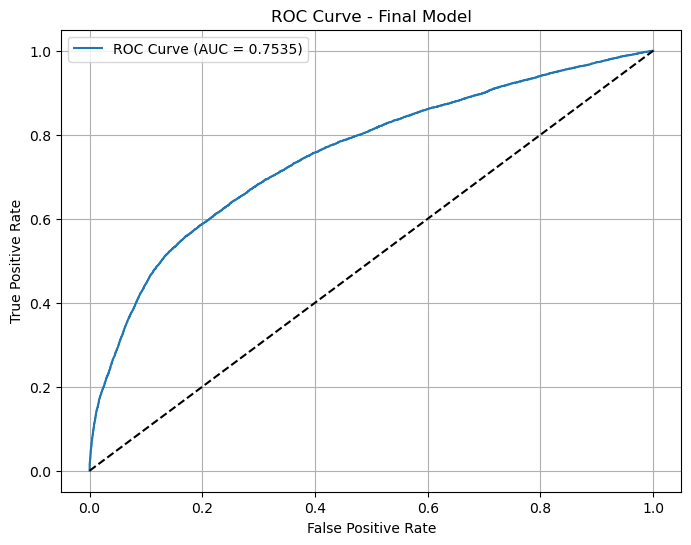

In [83]:
# ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.grid(True)
plt.show()

## DECILE / RISK-RANKING ANALYSIS

In [84]:
decile_df = pd.DataFrame({'Actual': y_test_B, 'Probability': y_prob_B})
decile_df['Decile'] = pd.qcut(decile_df['Probability'], 10, labels=False, duplicates='drop')
decile_df['Decile'] = 10 - decile_df['Decile']

In [85]:
decile_summary = (
    decile_df.groupby('Decile')
    .agg(Total=('Actual', 'count'), Default=('Actual', lambda x: (x == 1).sum()))
)
decile_summary['Good'] = decile_summary['Total'] - decile_summary['Default']
decile_summary['Default Rate (%)'] = decile_summary['Default'] / decile_summary['Total'] * 100
decile_summary['Cum Default'] = decile_summary['Default'].cumsum()
decile_summary['Cum Default %'] = decile_summary['Cum Default'] / decile_summary['Default'].sum() * 100

In [86]:
decile_summary = decile_summary.sort_index()
print(decile_summary)

        Total  Default  Good  Default Rate (%)  Cum Default  Cum Default %
Decile                                                                    
1        4460     2990  1470         67.040359         2990      27.201601
2        4460     2187  2273         49.035874         5177      47.097889
3        4461     1326  3135         29.724277         6503      59.161208
4        4459     1052  3407         23.592734         7555      68.731805
5        4460      862  3598         19.327354         8417      76.573872
6        4460      667  3793         14.955157         9084      82.641921
7        4460      551  3909         12.354260         9635      87.654658
8        4460      533  3927         11.950673        10168      92.503639
9        4460      439  4021          9.843049        10607      96.497453
10       4461      385  4076          8.630352        10992     100.000000
